<a href="https://colab.research.google.com/github/the1975/python_learning/blob/main/ProjectDataProcessingSentimen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***“Analisis Sentimen Masyarakat terhadap Pernyataan Prabowo Mengenai Pelemahan Nilai Rupiah Menggunakan Machine Learning”***

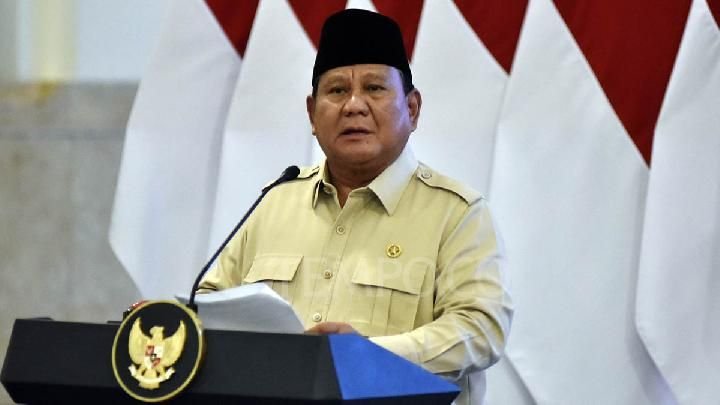

*sumber analisis : youtube (3 Juni 2026)*

**1. install library yang dibutuhkan**

In [ ]:
# install library untuk akses youtube API
!pip install google-api-python-client pandas

In [ ]:
# install libraryuntuk manipulasi data
!pip install pandas -q

In [ ]:
# install library untuk analisis sentimen (model IndoBERT)
!pip install transformers torch -q

In [ ]:
# install library untuk visualisasi grafik
!pip install matplotlib -q

In [ ]:
# install library untuk wordcloud
!pip install wordcloud -q

In [ ]:
# install library untuk machine learning
!pip install scikit-learn -q

**2. import library yang dibutuhkan**

In [ ]:
# import library akses secret
from google.colab import userdata

# akses youtube data api
from googleapiclient.discovery import build

# manipulasi dan analisis data
import pandas as pd

# operasi regex untuk preprocessing teks
import re

# visualisasi grafik
import matplotlib.pyplot as plt

# analisis sentimen
from transformers import pipeline

# wordcloud
from wordcloud import WordCloud

# menghitung frekuensi data
from collections import Counter

# progress bar saat prediksi sentimen
from tqdm import tqdm

# Machine learning
from sklearn.model_selection     import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing       import LabelEncoder
from sklearn.naive_bayes         import MultinomialNB
from sklearn.svm                 import LinearSVC
from sklearn.ensemble            import RandomForestClassifier
from sklearn.metrics             import (accuracy_score, precision_score,
                                         recall_score, f1_score,
                                         confusion_matrix, ConfusionMatrixDisplay,
                                         classification_report)

print("✅ Library siap!")

✅ Library siap!


**3. setting data yang mau diambil (konfigurasi)**

In [ ]:
# setting

# API key dari google cloud platform
API_KEY = userdata.get('API_KEY')

# kata kunci pencarian video di youtube
QUERY      = "prabowo rupiah"

# jumlah video yang ingin diambil
MAX_VIDEOS = 30

# inisialisasi youtube API
youtube = build("youtube", "v3", developerKey=API_KEY)
print("Koneksi berhasil!")

Koneksi berhasil!


**4. buat function buat cari video**

In [ ]:
# function buat cari video
def cari_video(query, max_results):
    response = youtube.search().list(
        q=query,
        part="snippet",
        type="video",
        maxResults=max_results,
        relevanceLanguage="id",
        order="relevance"
    ).execute()

    videos = [
        {
            "video_id" : item["id"]["videoId"],
            "judul"    : item["snippet"]["title"],
            "channel"  : item["snippet"]["channelTitle"],
            "tanggal"  : item["snippet"]["publishedAt"]
        }
        for item in response["items"]
    ]
    return videos

**5. buat funtion buat ambil komentar video**

In [ ]:
# function buat ambil komentar
def ambil_komentar(video_id):
    komentar_list = []
    next_page_token = None

    try:
        while True:
            response = youtube.commentThreads().list(
                part="snippet",
                videoId=video_id,
                maxResults=100,
                textFormat="plainText",
                order="relevance",
                pageToken=next_page_token
            ).execute()

            for item in response["items"]:
                snip = item["snippet"]["topLevelComment"]["snippet"]
                komentar_list.append({
                    "video_id"  : video_id,
                    "nama_user" : snip["authorDisplayName"],
                    "komentar"  : snip["textDisplay"],
                    "likes"     : snip["likeCount"],
                    "tanggal"   : snip["publishedAt"]
                })

            # Cek apakah masih ada halaman berikutnya
            next_page_token = response.get("nextPageToken")
            if not next_page_token:
                break  # Stop kalau sudah tidak ada halaman lagi

    except Exception as e:
        print(f"⚠️ Video {video_id} dilewati: {e}")

    return komentar_list

**6. jalankan dan simpan jadi csv**

In [ ]:
# cari video
print("🔍 Mencari video...")
videos = cari_video(QUERY, MAX_VIDEOS)
print(f"✅ {len(videos)} video ditemukan\n")

# ambil komentar dari setiap video
print("💬 Mengambil komentar...")
semua_komentar = []
for v in videos:
    print(f"  → {v['judul'][:55]}...")
    komentar = ambil_komentar(v["video_id"])  # tanpa MAX_COMMENTS
    semua_komentar.extend(komentar)
    print(f"     {len(komentar)} komentar didapat")

# simpan file ke csv
df = pd.DataFrame(semua_komentar)
df.to_csv("data_komentar_youtube.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ SELESAI! Total {len(semua_komentar)} komentar")
print("📁 File: data_komentar_youtube.csv")

🔍 Mencari video...
✅ 30 video ditemukan

💬 Mengambil komentar...
  → Nilai Tukar Rupiah Melemah, Prabowo: Rakyat di Desa Eng...
     472 komentar didapat
  → Rupiah Melemah hingga Tembus Rp 17 Ribu Lebih, Prabowo:...
     901 komentar didapat
  → Rupiah Melemah! Purbaya, Puan hingga Presiden Prabowo R...
     65 komentar didapat
  → Kocak! Kompilasi Netizen Respon Ucapan Prabowo &quot;Or...
     851 komentar didapat
  → Ekonom Sebut Prabowo Dibohongi Soal Sebut Orang Desa Ta...
     49 komentar didapat
  → Unggahan Lampau Prabowo Mencuat di Tengah Rupiah yang T...
     414 komentar didapat
  → Perjalanan Nilai Rupiah di Era Tiap Presiden, dari Habi...
     2 komentar didapat
  → Prabowo soal Rupiah Melemah: Orang Desa Enggak Pakai Do...
     206 komentar didapat
  → Kelakar Prabowo soal Rupiah yang Terus Melemah: Rakyat ...
     27 komentar didapat
  → Rupiah Melemah, Prabowo: Rakyat di Desa Enggak Pakai Do...
     95 komentar didapat
  → bikin malu pernyataan konyol prabowo soal pelem

**7. preprocessing (bersihkan komentar)**

In [ ]:
# funtion preprocessing
def bersihkan_teks(teks):
    teks = teks.lower()                            # lowercase
    teks = re.sub(r'http\S+', '', teks)            # hapus link
    teks = re.sub(r'@\w+', '', teks)              # hapus mention
    teks = re.sub(r'#\w+', '', teks)              # hapus hashtag
    teks = re.sub(r'[^\w\s]', '', teks)           # hapus tanda baca
    teks = re.sub(r'\d+', '', teks)               # hapus angka
    teks = re.sub(r'\s+', ' ', teks).strip()      # hapus spasi berlebih
    return teks

# Load CSV
df = pd.read_csv("data_komentar_youtube.csv")

# Bersihkan
df["komentar_bersih"] = df["komentar"].astype(str).apply(bersihkan_teks)

# Hapus yang kosong
df = df[df["komentar_bersih"].str.strip() != ""]
df = df.drop_duplicates(subset=["komentar_bersih"])

print(f"✅ Data setelah preprocessing: {len(df)} komentar")
df.head(25)

✅ Data setelah preprocessing: 6310 komentar


,video_id,nama_user,komentar,likes,tanggal,komentar_bersih
0,uAZxinOQx-E,@Userrrr-fv7cp,Didesa ga pake dollar begitupun dikota ga ada ...,154,2026-05-16T14:22:16Z,didesa ga pake dollar begitupun dikota ga ada ...
1,uAZxinOQx-E,@ALUXJAMBECHANNEL181079,"Dia pikir rakyat bodoh, sebagian besar BBM kit...",205,2026-05-16T15:21:38Z,dia pikir rakyat bodoh sebagian besar bbm kita...
2,uAZxinOQx-E,@alvinwahdanilmufid518,Jawaban seperti org tidak berpendidikan. Padah...,37,2026-05-16T16:58:22Z,jawaban seperti org tidak berpendidikan padaha...
3,uAZxinOQx-E,@LembahManahfarm,Kami di desa sgt berat barang2 kebutuhan pokok...,32,2026-05-16T15:30:42Z,kami di desa sgt berat barang kebutuhan pokok ...
4,uAZxinOQx-E,@fegito9206,Sedih saya Pak. Saya juga bukan tinggal di kot...,14,2026-05-17T09:17:31Z,sedih saya pak saya juga bukan tinggal di kota...
5,uAZxinOQx-E,@avinarshavin8549,"Kedelai bahan tempe tahu impor pak, belinya pa...",36,2026-05-16T15:44:07Z,kedelai bahan tempe tahu impor pak belinya pak...
6,uAZxinOQx-E,@Heeyosh1t,gw yakin nih orang pas sekolah ranking terakhi...,3,2026-05-17T02:01:58Z,gw yakin nih orang pas sekolah ranking terakhi...
7,uAZxinOQx-E,@irfanardiansyah8939,rakyat kecil full menderita semenjak bapak men...,0,2026-05-27T08:25:15Z,rakyat kecil full menderita semenjak bapak men...
8,uAZxinOQx-E,@gilanglesmana590,Kok pemimpin kita begini ya...??? Bahas melema...,1,2026-05-20T05:11:16Z,kok pemimpin kita begini ya bahas melemahnya r...
9,uAZxinOQx-E,@tidakdiketahui801,"Karena anda tidak berkompeten bapak, apa apa y...",1,2026-05-20T07:37:34Z,karena anda tidak berkompeten bapak apa apa yg...


**8. analisis sentimen pake IndoBERT**

In [ ]:
# model RoBERTa berbasis bahasa indonesia
print("⏳ Loading model IndoBERT... (tunggu sebentar)")
sentiment_model = pipeline(
    "text-classification",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    truncation=True,
    max_length=512
)
print("✅ Model siap!")

⏳ Loading model IndoBERT... (tunggu sebentar)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model siap!


**9. prediksi sentimen**

In [ ]:
# prediksi sentimen setiap komentar menggunakan IndoBERT
tqdm.pandas()

def prediksi_sentimen(teks):
    try:
        hasil = sentiment_model(teks[:512])[0]
        return hasil["label"], round(hasil["score"], 4)
    except:
        return "netral", 0.0

print("🔍 Memproses sentimen... (ini butuh beberapa menit)")
df[["sentimen", "confidence"]] = df["komentar_bersih"].progress_apply(
    lambda x: pd.Series(prediksi_sentimen(x))
)

# Simpan hasil
df.to_csv("data_sentimen.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ Selesai!")
print(df["sentimen"].value_counts())

🔍 Memproses sentimen... (ini butuh beberapa menit)


100%|██████████| 6310/6310 [13:26<00:00,  7.83it/s]


✅ Selesai!
sentimen
negative    4689
neutral     1006
positive     615
Name: count, dtype: int64


**10. persiapan data visualisasi**

In [ ]:
# hitung jumlah dan presentase tiap sentimen
summary = df["sentimen"].value_counts().reset_index()
summary.columns = ["Sentimen", "Jumlah"]
summary["Persentase"] = (summary["Jumlah"] / len(df) * 100).round(2)

# palet warna tiap sentimen
WARNA = {
    "positive": "#2ecc71",
    "neutral" : "#3498db",
    "negative": "#e74c3c"
}
warna = [WARNA.get(s, "#95a5a6") for s in summary["Sentimen"]]

print("✅ Data siap!")
print(summary)

✅ Data siap!
   Sentimen  Jumlah  Persentase
0  negative    4689       74.31
1   neutral    1006       15.94
2  positive     615        9.75


**11. bar chart**

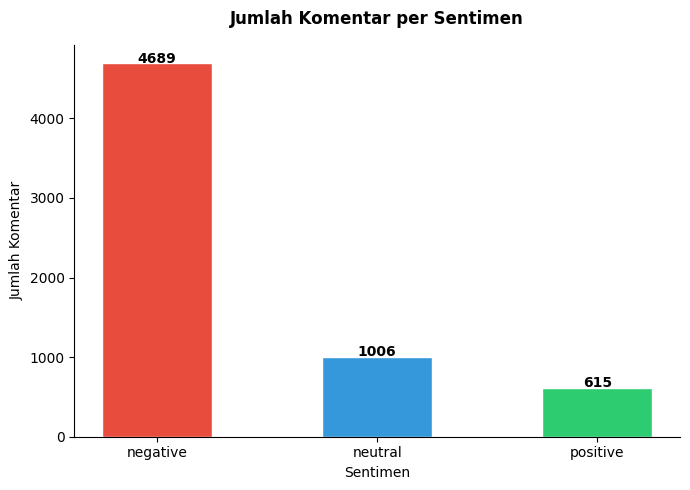

In [ ]:
# grafik 1 - bar chart jumlah komentar
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(summary["Sentimen"], summary["Jumlah"], color=warna, width=0.5, edgecolor="white")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha="center", fontweight="bold"
    )

ax.set_title("Jumlah Komentar per Sentimen", fontweight="bold", pad=15)
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah Komentar")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafik_bar.png", dpi=150, bbox_inches="tight")
plt.show()

**12. pie chart**

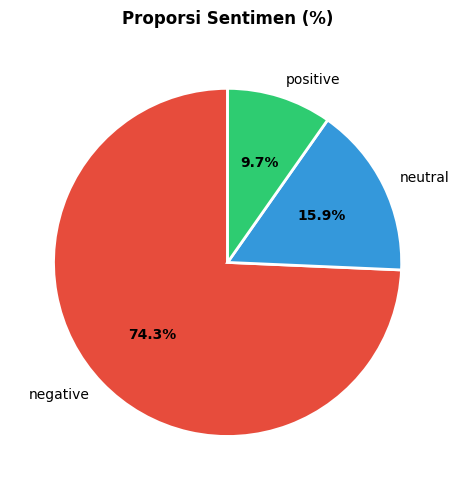

In [ ]:
# grafik 2 - pie chart presentase sentimen
fig, ax = plt.subplots(figsize=(7, 5))

wedges, texts, autotexts = ax.pie(
    summary["Jumlah"],
    labels=summary["Sentimen"],
    colors=warna,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

for at in autotexts:
    at.set_fontweight("bold")

ax.set_title("Proporsi Sentimen (%)", fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("grafik_pie.png", dpi=150, bbox_inches="tight")
plt.show()

**13. horizontal bar**

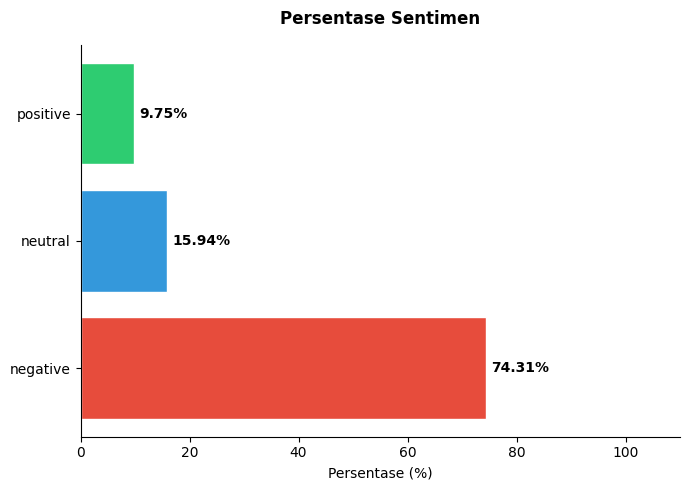

In [ ]:
# grafik 3 - horizontal bar chart jumlah komentar
fig, ax = plt.subplots(figsize=(7, 5))

hbars = ax.barh(summary["Sentimen"], summary["Persentase"], color=warna, edgecolor="white")

for bar in hbars:
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width()}%",
        va="center", fontweight="bold"
    )

ax.set_title("Persentase Sentimen", fontweight="bold", pad=15)
ax.set_xlabel("Persentase (%)")
ax.set_xlim(0, 110)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafik_hbar.png", dpi=150, bbox_inches="tight")
plt.show()

**14. tabel ringkasan**

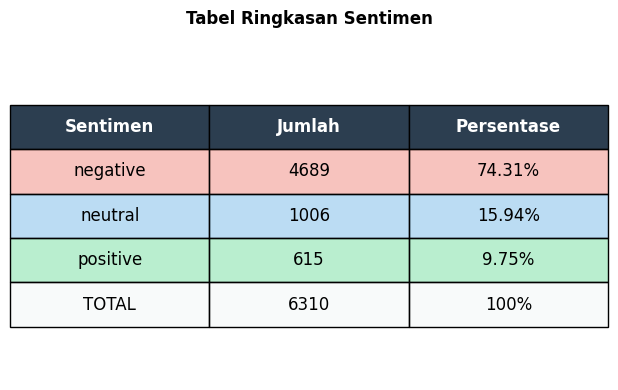

In [ ]:
# grafik 4 - tabel ringkasan sentimen
fig, ax = plt.subplots(figsize=(7, 4))
ax.axis("off")

tabel_data = [
    (row["Sentimen"], row["Jumlah"], f"{row['Persentase']}%")
    for _, row in summary.iterrows()
]
tabel_data.append(("TOTAL", len(df), "100%"))

table = ax.table(
    cellText=tabel_data,
    colLabels=["Sentimen", "Jumlah", "Persentase"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2.5)

# Warna header
for j in range(3):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Warna baris
for i, row in enumerate(tabel_data):
    warna_baris = WARNA.get(row[0], "#ecf0f1")
    for j in range(3):
        table[i+1, j].set_facecolor(warna_baris + "55")

ax.set_title("Tabel Ringkasan Sentimen", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("grafik_tabel.png", dpi=150, bbox_inches="tight")
plt.show()

**15. wordcloud semua komentar**

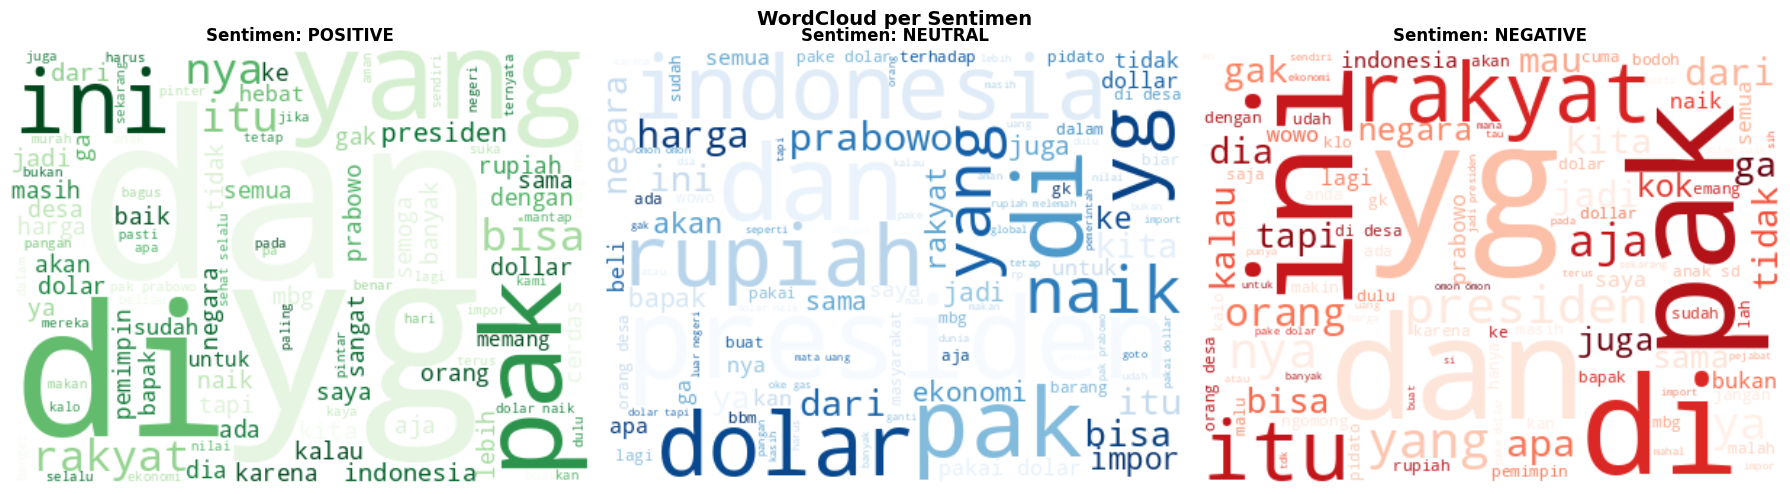

In [ ]:
# eda - wordcloud per sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentimen, colormap in zip(
    axes,
    ["positive", "neutral", "negative"],
    ["Greens",   "Blues",   "Reds"]
):
    teks = " ".join(df[df["sentimen"] == sentimen]["komentar_bersih"].tolist())

    if teks.strip():
        wc = WordCloud(
            width=400, height=300,
            background_color="white",
            colormap=colormap,
            max_words=100
        ).generate(teks)
        ax.imshow(wc, interpolation="bilinear")

    ax.axis("off")
    ax.set_title(f"Sentimen: {sentimen.upper()}", fontweight="bold")

plt.suptitle("WordCloud per Sentimen", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("wordcloud_per_sentimen.png", dpi=150, bbox_inches="tight")
plt.show()

**16. top 10 kata per sentimen**

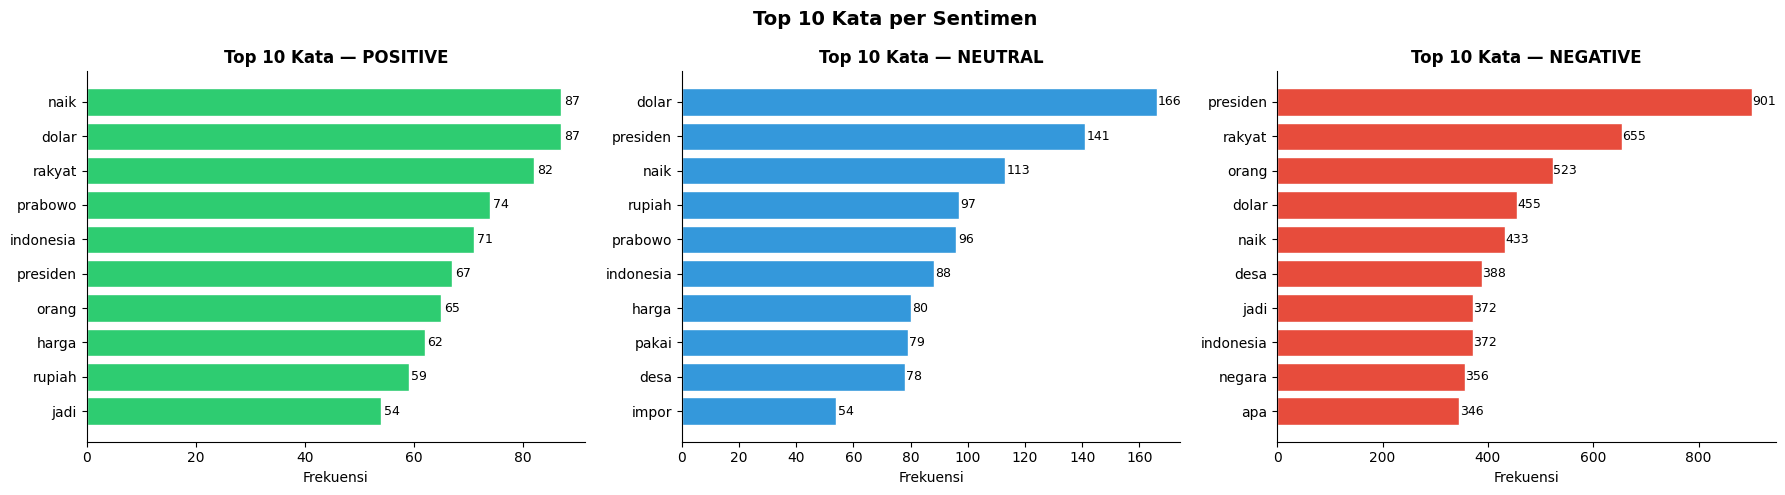

In [ ]:
# eda - 10 kata per sentimen
STOPWORDS = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "dengan",
    "untuk", "tidak", "ya", "ada", "juga", "bisa", "kita", "si",
    "nya", "aja", "sih", "dong", "lah", "kan", "nih", "gak", "ga",
    "pak", "bu", "mas", "bang", "kok", "mah", "tuh", "deh", "yg"
}

def top_kata(sentimen, n=10):
    teks = " ".join(df[df["sentimen"] == sentimen]["komentar_bersih"].tolist())
    kata = [w for w in teks.split() if w not in STOPWORDS and len(w) > 2]
    return Counter(kata).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentimen_list = [("positive", "#2ecc71"), ("neutral", "#3498db"), ("negative", "#e74c3c")]

for ax, (sentimen, warna) in zip(axes, sentimen_list):
    data   = top_kata(sentimen)
    kata   = [k[0] for k in data]
    jumlah = [k[1] for k in data]

    bars = ax.barh(kata[::-1], jumlah[::-1], color=warna, edgecolor="white")
    ax.set_title(f"Top 10 Kata — {sentimen.upper()}", fontweight="bold")
    ax.set_xlabel("Frekuensi")
    ax.spines[["top", "right"]].set_visible(False)

    for bar in bars:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(int(bar.get_width())), va="center", fontsize=9)

plt.suptitle("Top 10 Kata per Sentimen", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("top_kata.png", dpi=150, bbox_inches="tight")
plt.show()

**17. tren waktu filter komentar sekarang**

Total data setelah filter: 6310 komentar
Rentang tanggal: 2026-01-20 s/d 2026-06-03


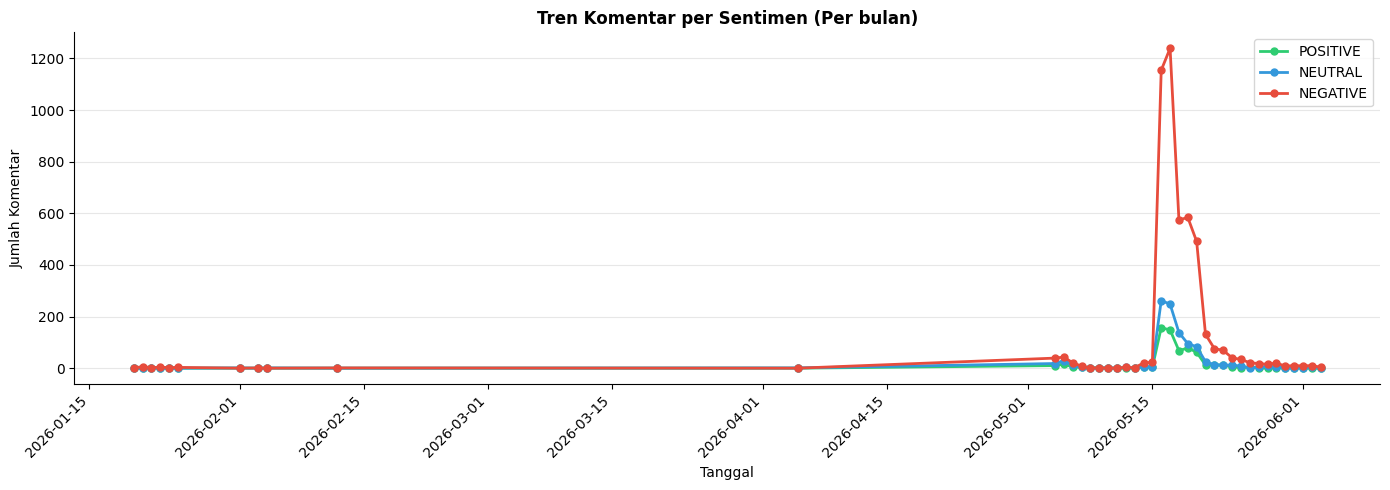

In [ ]:
df["tanggal"] = pd.to_datetime(df["tanggal"])

# Filter hanya komentar 2025 ke atas
df_filtered = df[df["tanggal"].dt.year >= 2025].copy()
df_filtered["Bulan"] = df_filtered["tanggal"].dt.date

print(f"Total data setelah filter: {len(df_filtered)} komentar")
print(f"Rentang tanggal: {df_filtered['Bulan'].min()} s/d {df_filtered['Bulan'].max()}")

tren = df_filtered.groupby(["Bulan", "sentimen"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))

for sentimen, warna in [("positive","#2ecc71"), ("neutral","#3498db"), ("negative","#e74c3c")]:
    if sentimen in tren.columns:
        ax.plot(tren.index, tren[sentimen], label=sentimen.upper(),
                color=warna, linewidth=2, marker="o", markersize=5)

ax.set_title("Tren Komentar per Sentimen (Per bulan)", fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah Komentar")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("tren_waktu.png", dpi=150, bbox_inches="tight")
plt.show()

**18. modeling ML**

In [ ]:
# modeling - persiapan data untuk machine learning
# Encode label
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentimen"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df["komentar_bersih"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ Train: {X_train_tfidf.shape[0]} data")
print(f"✅ Test : {X_test_tfidf.shape[0]} data")

✅ Train: 5048 data
✅ Test : 1262 data


**19. training dan evaluasi 3 mode**

In [ ]:
# Definisi model yang akan diuji
models = {
    "Naive Bayes"   : MultinomialNB(),
    "SVM"           : LinearSVC(max_iter=1000),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42)
}

hasil_evaluasi = []

for nama, model in models.items():
    # Training model
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)

    # Hitung metrik evaluasi
    hasil_evaluasi.append({
        "Model"    : nama,
        "Akurasi"  : round(accuracy_score(y_test, pred) * 100, 2),
        "Precision": round(precision_score(y_test, pred, average="weighted") * 100, 2),
        "Recall"   : round(recall_score(y_test, pred, average="weighted") * 100, 2),
        "F1-Score" : round(f1_score(y_test, pred, average="weighted") * 100, 2)
    })

    print(f"\n{'='*40}")
    print(f"Model   : {nama}")
    print(classification_report(y_test, pred, target_names=le.classes_))

# Urutkan berdasarkan F1-Score terbaik
df_eval = pd.DataFrame(hasil_evaluasi).sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("\n📊 TABEL EVALUASI SEMUA MODEL")
print("="*60)
print(df_eval.to_string(index=False))
print("="*60)
print(f"\n🏆 Model Terbaik: {df_eval.iloc[0]['Model']} (F1: {df_eval.iloc[0]['F1-Score']}%)")


Model   : Naive Bayes
              precision    recall  f1-score   support

    negative       0.75      1.00      0.86       938
     neutral       0.67      0.02      0.04       201
    positive       0.83      0.04      0.08       123

    accuracy                           0.75      1262
   macro avg       0.75      0.35      0.32      1262
weighted avg       0.74      0.75      0.65      1262


Model   : SVM
              precision    recall  f1-score   support

    negative       0.82      0.93      0.87       938
     neutral       0.56      0.36      0.44       201
    positive       0.54      0.28      0.37       123

    accuracy                           0.78      1262
   macro avg       0.64      0.52      0.56      1262
weighted avg       0.75      0.78      0.75      1262


Model   : Random Forest
              precision    recall  f1-score   support

    negative       0.78      0.97      0.87       938
     neutral       0.63      0.20      0.30       201
    positive

**20. grafik evaluasi dan confusion matrix**

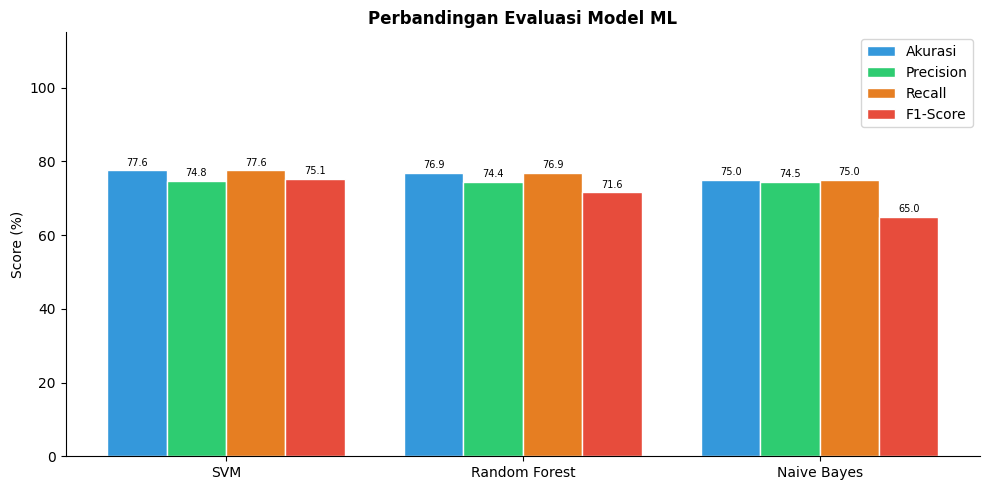

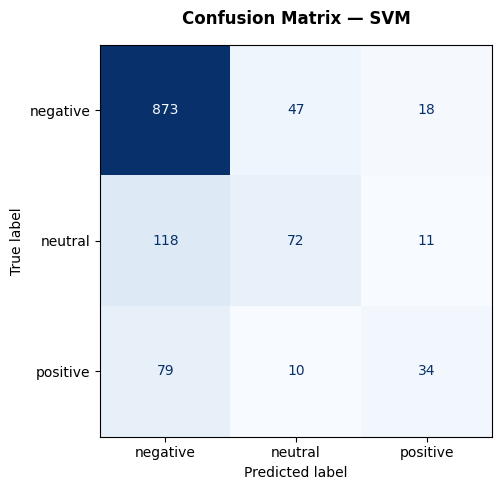

In [ ]:
# --- Grafik Perbandingan Akurasi ---
fig, ax = plt.subplots(figsize=(10, 5))

x     = range(len(df_eval))
width = 0.2

ax.bar([i - 1.5*width for i in x], df_eval["Akurasi"],   width, label="Akurasi",   color="#3498db", edgecolor="white")
ax.bar([i - 0.5*width for i in x], df_eval["Precision"], width, label="Precision", color="#2ecc71", edgecolor="white")
ax.bar([i + 0.5*width for i in x], df_eval["Recall"],    width, label="Recall",    color="#e67e22", edgecolor="white")
ax.bar([i + 1.5*width for i in x], df_eval["F1-Score"],  width, label="F1-Score",  color="#e74c3c", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(df_eval["Model"])
ax.set_ylim(0, 115)
ax.set_ylabel("Score (%)")
ax.set_title("Perbandingan Evaluasi Model ML", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f", fontsize=7, padding=2)

plt.tight_layout()
plt.savefig("evaluasi_model.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Confusion Matrix Model Terbaik ---
best_name  = df_eval.iloc[0]["Model"]
best_model = models[best_name]
pred_best  = best_model.predict(X_test_tfidf)
cm         = confusion_matrix(y_test, pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**21. laporan akhir**

In [ ]:
# ===================================================
# LAPORAN AKHIR & KESIMPULAN
# ===================================================

best_f1      = df_eval.iloc[0]["F1-Score"]
best_akurasi = df_eval.iloc[0]["Akurasi"]
dominan      = df["sentimen"].value_counts().idxmax()
dominan_pct  = round(df["sentimen"].value_counts(normalize=True).max() * 100, 2)

print("=" * 60)
print("      LAPORAN ANALISIS SENTIMEN YOUTUBE")
print("  Pernyataan Prabowo Mengenai Pelemahan Rupiah")
print("=" * 60)
print(f"""
📦 DATA
   Total Komentar  : {len(df)} komentar
   Jumlah Video    : {MAX_VIDEOS} video
   Query           : {QUERY}

📊 DISTRIBUSI SENTIMEN
   Positif  : {df['sentimen'].value_counts().get('positive', 0)} komentar
   Netral   : {df['sentimen'].value_counts().get('neutral', 0)} komentar
   Negatif  : {df['sentimen'].value_counts().get('negative', 0)} komentar

🏆 SENTIMEN DOMINAN  : {dominan.upper()} ({dominan_pct}%)

🤖 MODEL TERBAIK     : {best_name}
   Akurasi           : {best_akurasi}%
   F1-Score          : {best_f1}%
""")
print(df_eval.to_string(index=False))
print("=" * 60)

# Simpan laporan ke file teks
with open("laporan_hasil.txt", "w", encoding="utf-8") as f:
    f.write(f"Model Terbaik : {best_name}\n")
    f.write(f"Akurasi       : {best_akurasi}%\n")
    f.write(f"F1-Score      : {best_f1}%\n")
    f.write(f"Total Data    : {len(df)}\n")
    f.write(f"Dominan       : {dominan.upper()} ({dominan_pct}%)\n")

# Simpan data final
df.to_csv("data_final.csv", index=False, encoding="utf-8-sig")

print("""
✅ FILE TERSIMPAN:
   📁 data_final.csv
   📁 laporan_hasil.txt
   📁 grafik_bar.png
   📁 grafik_pie.png
   📁 grafik_hbar.png
   📁 grafik_tabel.png
   📁 wordcloud_per_sentimen.png
   📁 top_kata.png
   📁 tren_waktu.png
   📁 evaluasi_model.png
   📁 confusion_matrix.png

🎉 ANALISIS SELESAI!
""")

      LAPORAN ANALISIS SENTIMEN YOUTUBE
  Pernyataan Prabowo Mengenai Pelemahan Rupiah

📦 DATA
   Total Komentar  : 6310 komentar
   Jumlah Video    : 30 video
   Query           : prabowo rupiah

📊 DISTRIBUSI SENTIMEN
   Positif  : 615 komentar
   Netral   : 1006 komentar
   Negatif  : 4689 komentar

🏆 SENTIMEN DOMINAN  : NEGATIVE (74.31%)

🤖 MODEL TERBAIK     : SVM
   Akurasi           : 77.58%
   F1-Score          : 75.14%

        Model  Akurasi  Precision  Recall  F1-Score
          SVM    77.58      74.79   77.58     75.14
Random Forest    76.94      74.43   76.94     71.58
  Naive Bayes    74.96      74.46   74.96     65.03

✅ FILE TERSIMPAN:
   📁 data_final.csv
   📁 laporan_hasil.txt
   📁 grafik_bar.png
   📁 grafik_pie.png
   📁 grafik_hbar.png
   📁 grafik_tabel.png
   📁 wordcloud_per_sentimen.png
   📁 top_kata.png
   📁 tren_waktu.png
   📁 evaluasi_model.png
   📁 confusion_matrix.png

🎉 ANALISIS SELESAI!

